In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from keras import initializers
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm", "cosTheta"]   
TARGET_INT = ["X"]  
TARGET = ["DeltaX"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 3
TS = 0.07

In [14]:

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
SCALER = joblib.load("./scalers/scaler.pkl")    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [15]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_X,MSE_Train_1_X,R2_Train_2_X,MSE_Train_2_X,R2_Val_X,MSE_Val_X,R2_Test_1_X,MSE_Test_1_X,R2_Test_2_X,MSE_Test_2_X,R2_Test_3_X,MSE_Test_3_X
0,model_arch16_r0.01_Ld0.3_Lp0.7_seed1830,[16],0.3,0.7,0.01,1830,0.993112,0.000737,0.996430,0.000300,0.111348,0.084378,0.991289,0.000905,0.703758,0.024309,-2.272219,0.299216
1,model_arch16_r0.01_Ld0.3_Lp0.7_seed1940,[16],0.3,0.7,0.01,1940,0.679684,0.034250,0.653231,0.029147,-5.859437,0.651304,0.441517,0.058030,0.739191,0.021401,-11.149181,1.110935
2,model_arch16_r0.01_Ld0.3_Lp0.7_seed5679,[16],0.3,0.7,0.01,5679,0.996246,0.000401,0.997806,0.000184,-1.133329,0.202560,0.851785,0.015400,0.687113,0.025675,-3.373477,0.399916
3,model_arch16_r0.01_Ld0.3_Lp0.7_seed2408,[16],0.3,0.7,0.01,2408,0.995664,0.000464,0.996487,0.000295,0.157630,0.079983,0.909921,0.009360,0.783293,0.017782,-1.810610,0.257006
4,model_arch16_r0.01_Ld0.3_Lp0.7_seed7125,[16],0.3,0.7,0.01,7125,0.995287,0.000504,0.997365,0.000221,0.297651,0.066688,0.948162,0.005386,0.481486,0.042548,-1.901484,0.265315


In [16]:
def ComputeMean(table, target):
    r2_tr1 = f"R2_Train_1_{target}"
    r2_tr2 = f"R2_Train_2_{target}"
    r2_val = f"R2_Val_{target}"
    r2_t3 = f"R2_Test_3_{target}"
    
    cols = ["model", "Neurons", "reg",  r2_tr1, r2_tr2, r2_val, r2_t3]

    table = table[cols].copy()
    
    mean_values = table[[r2_tr1, r2_tr2, r2_val, r2_t3]].mean()

    mean_row = pd.DataFrame([{
        "model": "MEAN",
        "Neurons": "-",
        "reg": "-",
        r2_tr1: mean_values[r2_tr1],
        r2_tr2: mean_values[r2_tr2],
        r2_val: mean_values[r2_val],
        r2_t3: mean_values[r2_t3]
    }])

    table_mean = pd.concat([table, mean_row], ignore_index=True)
    display(table_mean)

def PickModels(df, target, tr1=0.0, tr2=0.0, v1=0.0, t3=0.0):

    r2_tr1 = f"R2_Train_1_{target}"
    r2_tr2 = f"R2_Train_2_{target}"
    r2_val = f"R2_Val_{target}"
    r2_t3 = f"R2_Test_3_{target}"

    # filtro mínimo
    filtered = df[
        (df[r2_tr1] > tr1) &
        (df[r2_tr2] > tr2) &
        (df[r2_t3] > t3) &
        (df[r2_val] > v1)
    ]

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # 🔹 melhor para cada métrica
    best_tr1 = filtered.sort_values(r2_tr1, ascending=False).iloc[0]
    best_tr2 = filtered.sort_values(r2_tr2, ascending=False).iloc[0]
    best_val = filtered.sort_values(r2_val, ascending=False).iloc[0]
    best_t3 = filtered.sort_values(r2_t3, ascending=False).iloc[0]

    selected = pd.DataFrame([best_tr1, best_tr2, best_val, best_t3]).drop_duplicates()
    ComputeMean(selected, target)
    return selected

In [17]:
def LoadModelFromRow(row):

    model_name = row["model"]

    model_path = f"models/{model_name}.keras"
    model = tf.keras.saving.load_model(model_path)

    return model

In [18]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [19]:
R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    # dtheta_cin = (R / (2 * L)) * (Wd - We)
    dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dx_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [20]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=0.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model, model_name):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)

    fig, axs = plt.subplots(
        n_datasets,
        2 * n_targets,
        figsize=(6 * 2 * n_targets, 4 * n_datasets)
    )

    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val": [],
            "R2_Test_1": [], "R2_Test_2": [], "R2_Test_3": [],
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val": [],
            "MSE_Test_1": [], "MSE_Test_2": [], "MSE_Test_3": [],
            "MSE_LSG_1": [], "MSE_LSG_2": [],
        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        dy_pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(dy_pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

        # =========================
        # MÉTRICAS + PLOTS
        # =========================
        for j, name in enumerate(TARGET_INT):

            # métricas (posição)
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, MSE = {mse:.4e}")

            # 🔹 coluna da posição (y)
            ax_y = axs[i, j] if n_datasets > 1 else axs[j]
            PlotOut(
                ax_y,
                TITLES[i],
                f"{name}",
                y_true[:, j],
                y_pred[:, j],
                y_cin[:, j]
            )

            # 🔹 coluna da derivada (dy)
            ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
            PlotOut(
                ax_dy,
                TITLES[i],
                f"d{name}",
                dy_true[:, j],
                dy_pred[:, j],
                dy_cin[:, j]
            )

    plt.tight_layout()
    return metrics

In [27]:
rows = PickModels(results, "X", tr1=0.0, tr2=0.0, v1=0.0, t3=0.0)

,model,Neurons,reg,R2_Train_1_X,R2_Train_2_X,R2_Val_X,R2_Test_3_X
0,model_arch264-128_r0.9_Ld0.3_Lp0.7_seed5679,"[264, 128]",0.9,0.993723,0.996307,0.592664,0.096131
1,model_arch32-16_r0.01_Ld0.7_Lp0.3_seed1940,"[32, 16]",0.01,0.983962,0.621324,0.714871,0.531262
2,MEAN,-,-,0.988842,0.808816,0.653767,0.313697


X | Train_1 -> R² = 0.9937, MSE = 6.7122e-04
X | Train_2 -> R² = 0.9963, MSE = 3.1037e-04
X | Test_1 -> R² = 0.5627, MSE = 4.5440e-02
X | Test_2 -> R² = -0.2347, MSE = 1.0131e-01
X | Test_3 -> R² = 0.0961, MSE = 8.2651e-02
X | Val -> R² = 0.5927, MSE = 3.8677e-02
X | LSG_1 -> R² = -0.5265, MSE = 1.5521e-01
X | LSG_2 -> R² = -3.3062, MSE = 3.7968e-01
X | Train_1 -> R² = 0.9840, MSE = 1.7148e-03
X | Train_2 -> R² = 0.6213, MSE = 3.1829e-02
X | Test_1 -> R² = -0.1324, MSE = 1.1767e-01
X | Test_2 -> R² = 0.0654, MSE = 7.6688e-02
X | Test_3 -> R² = 0.5313, MSE = 4.2862e-02
X | Val -> R² = 0.7149, MSE = 2.7073e-02
X | LSG_1 -> R² = 0.4868, MSE = 5.2182e-02
X | LSG_2 -> R² = -4.2977, MSE = 4.6710e-01


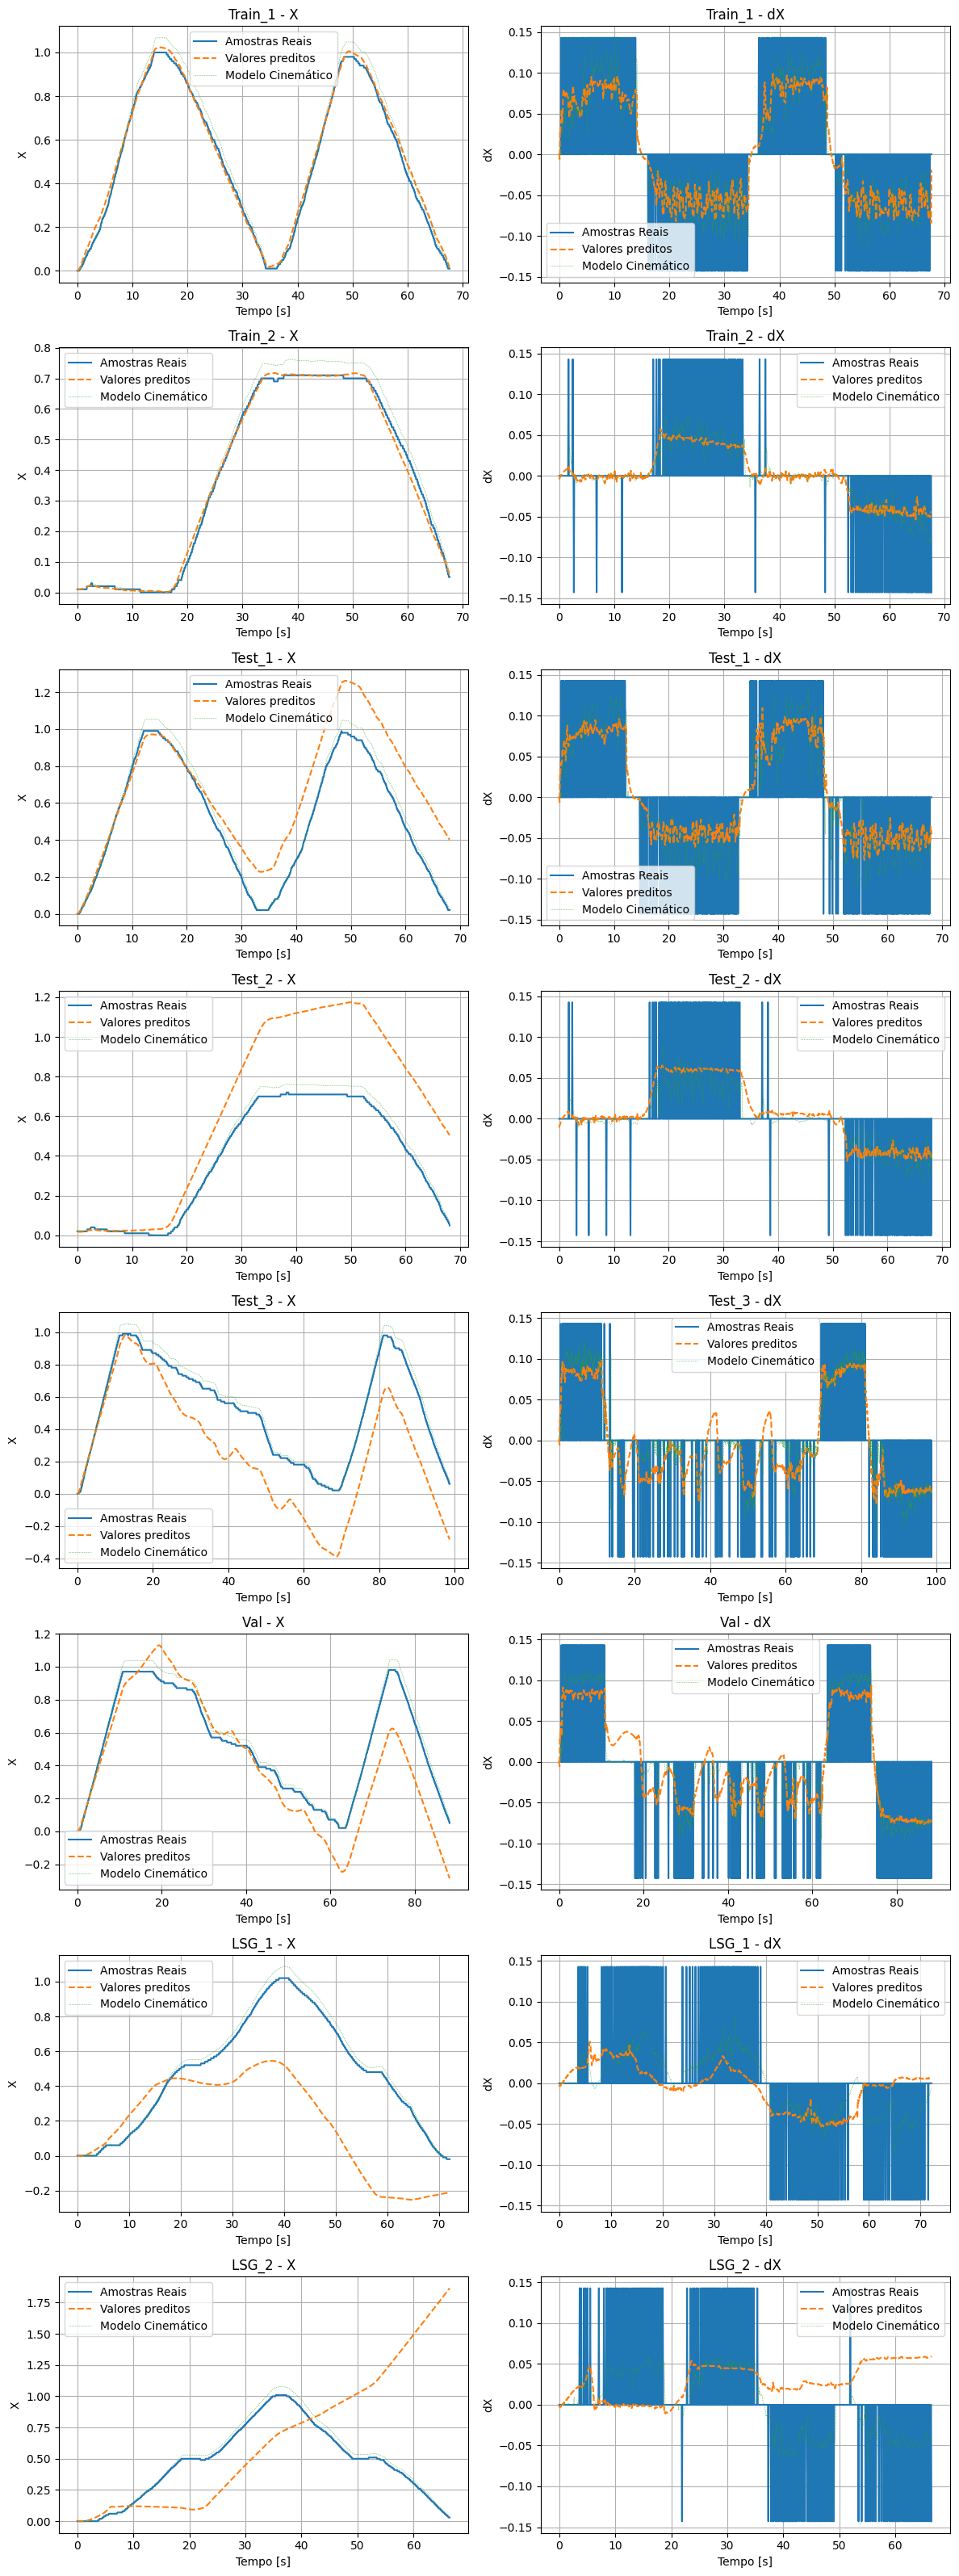

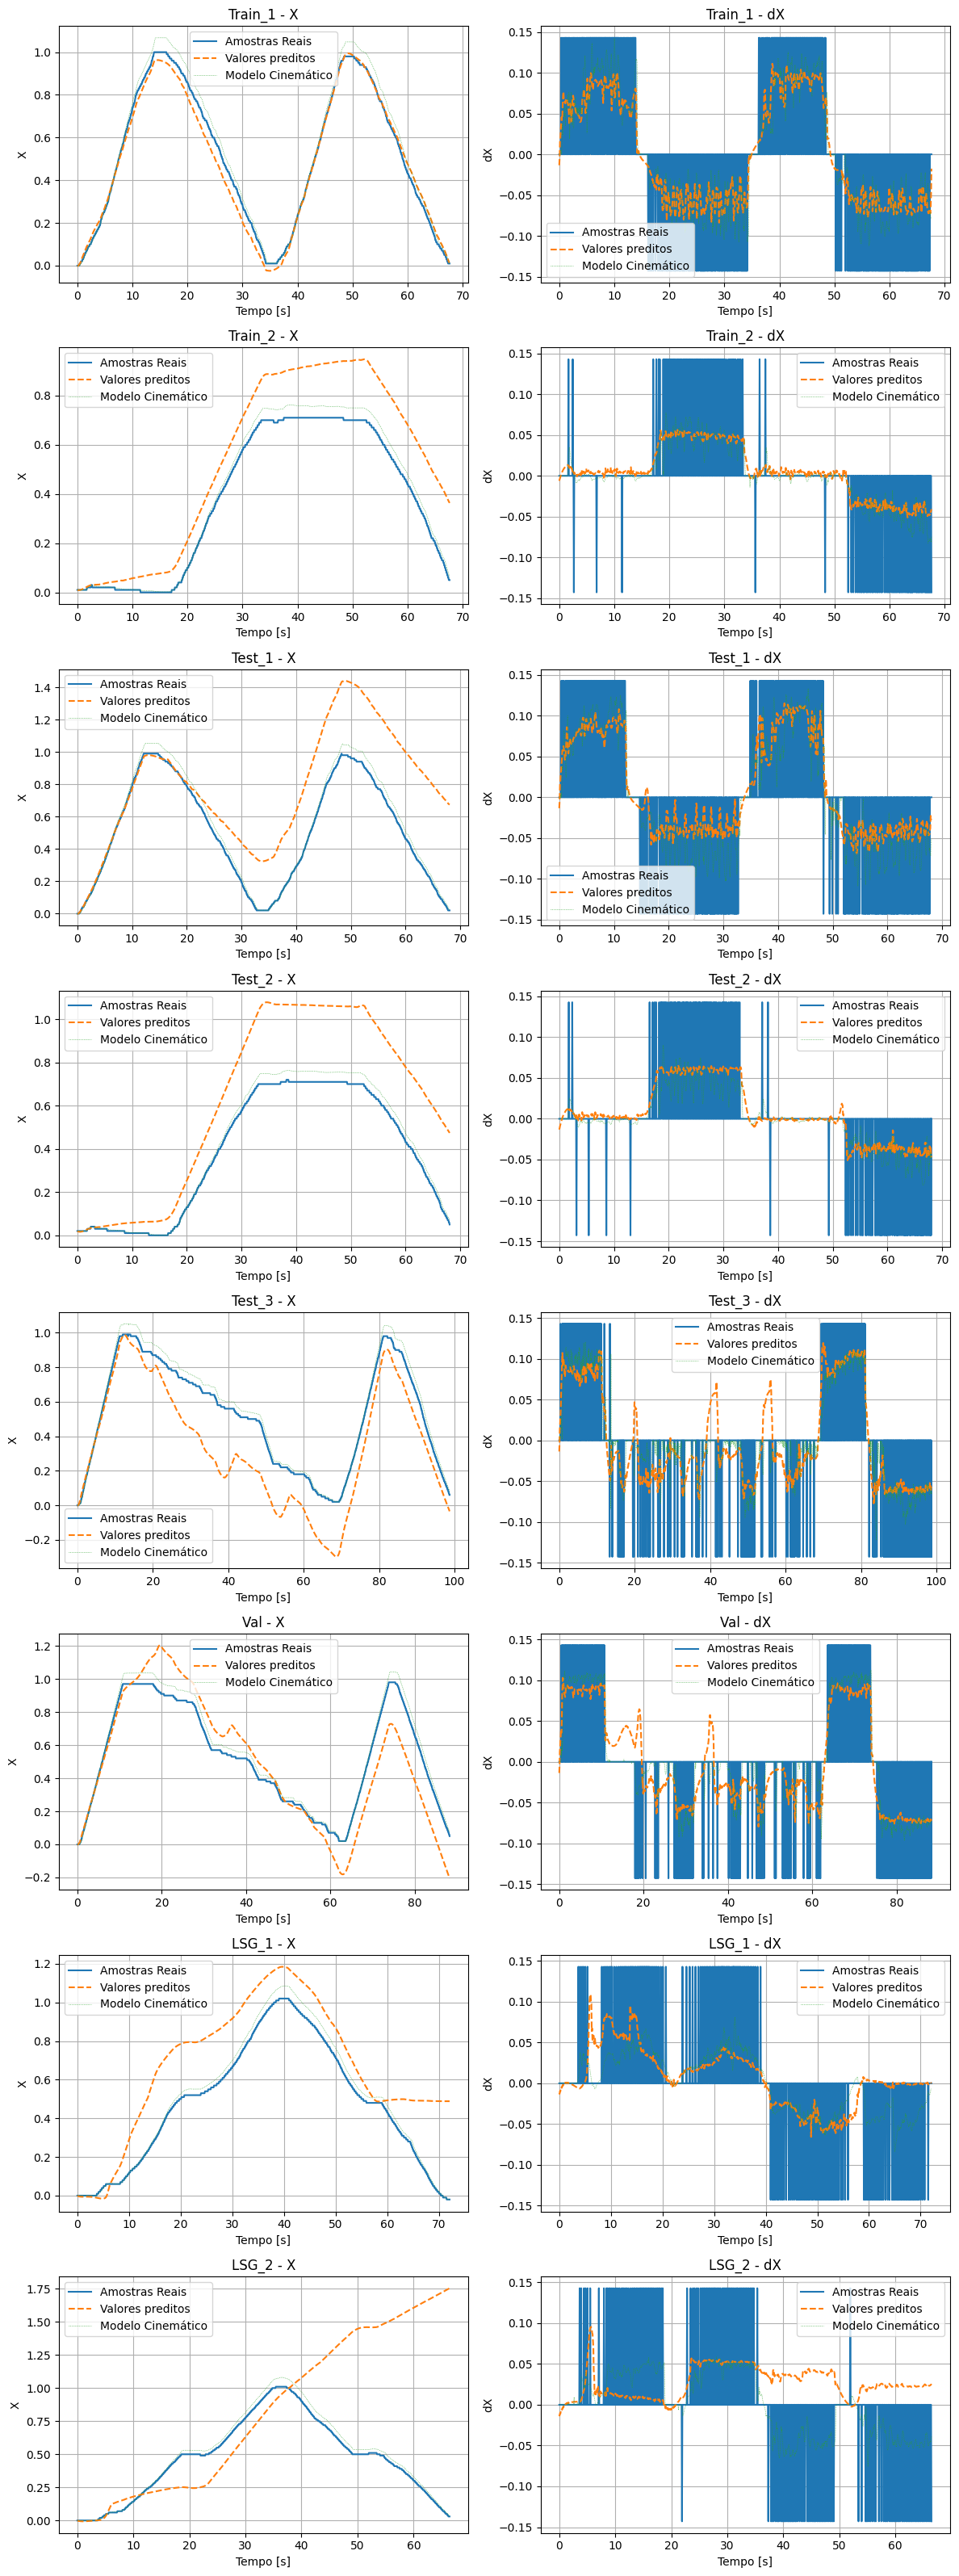

In [22]:
for i in range(len(rows)):
    row = rows.iloc[i]
    model_name = row["model"]
    model = LoadModelFromRow(row)
    metrics = EvalModel(model, model_name)

In [23]:
def ExportPredictionsExcel(models_dict, filename="predicoes.xlsx"):

    writer = pd.ExcelWriter(filename, engine="openpyxl")

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x_seq, y_seq = CreateSequences(x, y, TIME_STEPS)

        time = (np.arange(0, len(x_seq), 1) * TS).round(5)

        y_true = y_seq

        # modelo cinemático
        y_cin, dy_cin = GetCin(Datasets[i])
        y_cin = y_cin[:y_true.shape[0]]

        df = pd.DataFrame({
            "Tempo": time
        })

        # =========================
        # ENTRADAS
        # =========================
        for col in PREDICTORS:
            df[col] = Datasets[i][col].iloc[TIME_STEPS:].values

        # =========================
        # SAÍDA REAL
        # =========================
        for j, name in enumerate(TARGET_INT):
            df[f"{name}_real"] = y_true[:, j]

        # =========================
        # MODELO CINEMÁTICO
        # =========================
        for j, name in enumerate(TARGET_INT):
            df[f"{name}_cin"] = y_cin[:, j]

        # =========================
        # MODELOS TREINADOS
        # =========================
        for model_name, model in models_dict.items():

            dy_pred = model(tf.convert_to_tensor(x_seq, dtype=tf.float32)).numpy()
            dy_pred = OUT_SCALER.inverse_transform(dy_pred)

            y_pred = np.zeros_like(dy_pred)

            init_vals = np.array([
                Datasets[i][name].iloc[0] for name in TARGET_INT
            ])

            for j in range(len(TARGET_INT)):
                y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

            for j, name in enumerate(TARGET_INT):
                df[f"{name}_pred_{model_name}"] = y_pred[:, j]

        # nome da sheet (limite Excel = 31 chars)
        sheet_name = TITLES[i][:31]

        df.to_excel(writer, sheet_name=sheet_name, index=False)

    writer.close()
    print(f"Excel salvo em: {filename}")

In [28]:
models_dict = {}
for _, row in rows.iterrows():
    model_name = row["model"]
    model = LoadModelFromRow(row)
    models_dict[model_name] = model

ExportPredictionsExcel(models_dict, "resultados_comparacao.xlsx")

Excel salvo em: resultados_comparacao.xlsx


In [25]:
def EnsembleFromExcel(input_file, weights, output_metrics="Metricas.xlsx"):

    # normalizar pesos
    total_w = sum(weights.values())
    weights = {k: v / total_w for k, v in weights.items()}

    xls = pd.ExcelFile(input_file)

    metrics = []

    writer = pd.ExcelWriter(input_file, engine="openpyxl", mode="a", if_sheet_exists="replace")

    for sheet in xls.sheet_names:

        df = pd.read_excel(xls, sheet_name=sheet)

        # detectar targets automaticamente
        targets = list(set([col.split("_")[0] for col in df.columns if "_real" in col]))

        for target in targets:

            # =========================
            # COLUNAS
            # =========================
            y_true = df[f"{target}_real"].values

            # modelos disponíveis no df
            model_cols = {
                name: f"{target}_pred_{name}"
                for name in weights.keys()
                if f"{target}_pred_{name}" in df.columns
            }

            # =========================
            # ENSEMBLE
            # =========================
            y_ens = np.zeros_like(y_true, dtype=float)

            for model_name, col in model_cols.items():
                y_ens += weights[model_name] * df[col].values

            # salvar no dataframe
            df[f"{target}_ens"] = y_ens

            # =========================
            # MÉTRICAS
            # =========================
            # modelos individuais
            for model_name, col in model_cols.items():

                r2 = r2_score(y_true, df[col].values)
                mse = mean_squared_error(y_true, df[col].values)

                metrics.append({
                    "Dataset": sheet,
                    "Target": target,
                    "Model": model_name,
                    "R2": r2,
                    "MSE": mse
                })

            # ensemble
            r2_ens = r2_score(y_true, y_ens)
            mse_ens = mean_squared_error(y_true, y_ens)

            metrics.append({
                "Dataset": sheet,
                "Target": target,
                "Model": "ENSEMBLE",
                "R2": r2_ens,
                "MSE": mse_ens
            })

        # sobrescrever sheet com ensemble
        df.to_excel(writer, sheet_name=sheet, index=False)

    writer.close()

    # =========================
    # SALVAR MÉTRICAS
    # =========================
    df_metrics = pd.DataFrame(metrics)

    with pd.ExcelWriter(output_metrics, engine="openpyxl") as writer:

        df_metrics.to_excel(writer, sheet_name="raw", index=False)

        # pivot R2
        pivot_r2 = df_metrics.pivot_table(
            index=["Dataset", "Target"],
            columns="Model",
            values="R2"
        )

        # pivot MSE
        pivot_mse = df_metrics.pivot_table(
            index=["Dataset", "Target"],
            columns="Model",
            values="MSE"
        )

        pivot_r2.to_excel(writer, sheet_name="R2")
        pivot_mse.to_excel(writer, sheet_name="MSE")

    print("✔ Ensemble adicionado ao Excel original")
    print(f"✔ Métricas salvas em: {output_metrics}")

In [29]:
weights = {
    "model_arch264-128_r0.9_Ld0.3_Lp0.7_seed5679": 0.5,
    "model_arch32-16_r0.01_Ld0.7_Lp0.3_seed1940": 0.5,
}

EnsembleFromExcel("resultados_comparacao.xlsx", weights)

✔ Ensemble adicionado ao Excel original
✔ Métricas salvas em: Metricas.xlsx
